# **Accounting for seasonality(SARIMA)**

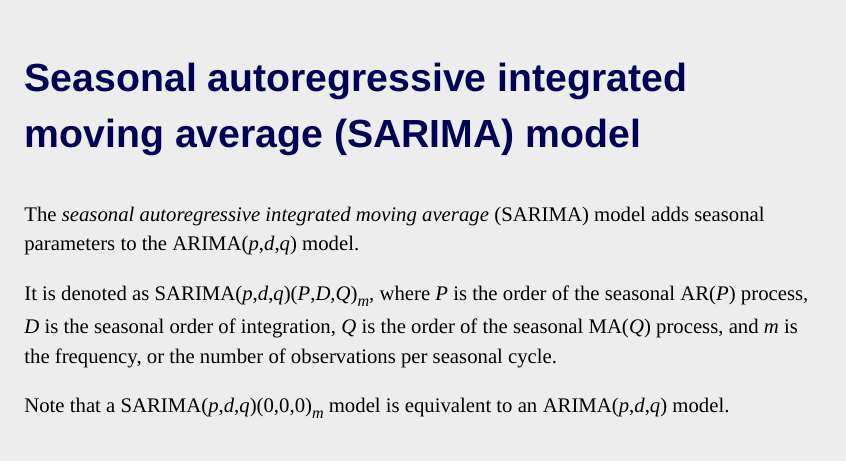

**The parameter m stands for the frequency. In the context of a time series, the
frequency is defined as the number of observations per cycle. The length of
the cycle will depend on the dataset. For data that was recorded every year,
quarter, month, or week, the length of a cycle is considered to be 1 year. If
the data was recorded annually, m = 1 since there is only one observation per
year. If the data was recorded quarterly, m = 4 since there are four quarters in
a year, and therefore four observations per year. Of course, if the data was
recorded monthly, m = 12. Finally, for weekly data, m = 52. Table 8.1
indicates the appropriate value of m depending on the frequency at which the
data was collected.**

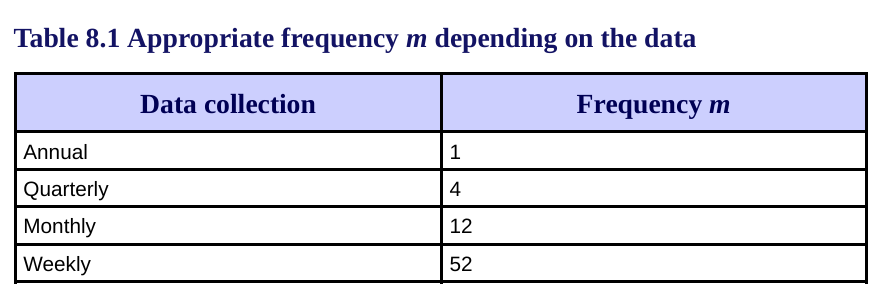

**When data is collected on a daily or sub-daily basis, there are multiple ways
of interpreting the frequency. For example, daily data can have a weekly
seasonality. In that case, the frequency is m = 7 because there would be
seven observations in a full cycle of 1 week. It could also have a yearly
seasonality, meaning that m = 365. Thus, you can see that daily and sub
daily data can have a different cycle length, and therefore a different
frequency m.**

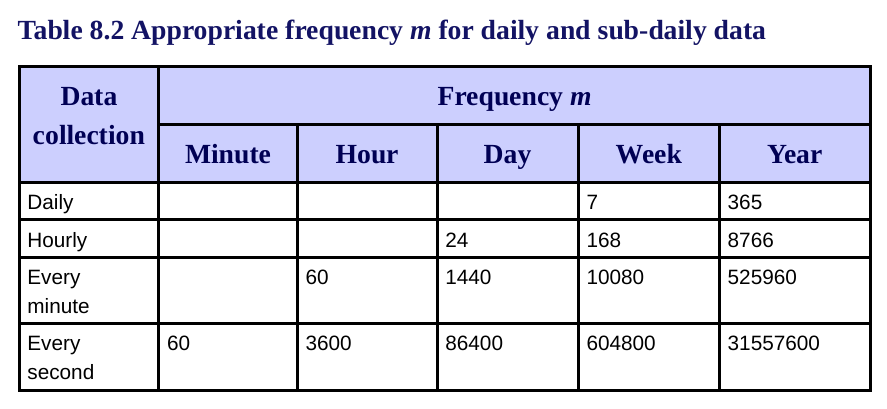

*Now that you understand the parameter m, the meanings of P, D, and Q
become intuitive. As mentioned before, they are the seasonal counterparts of
the p, d, and q parameters that you know from the ARIMA(p,d,q) model.*

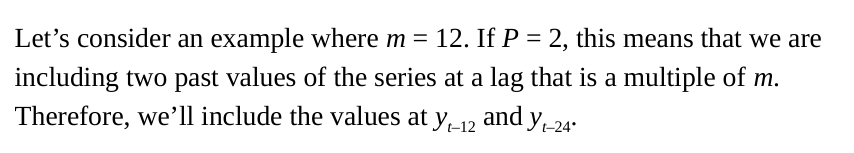
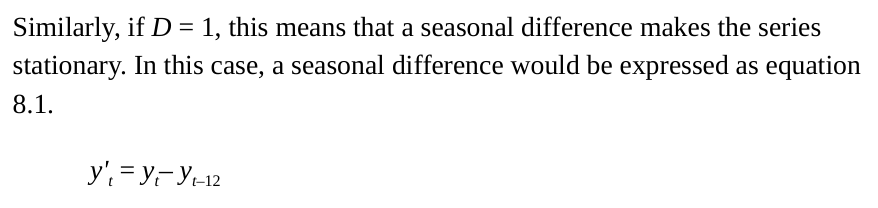
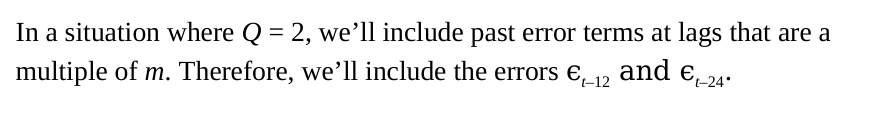

*Let’s put this into perspective using the airline’s total monthly air passengers
dataset. We know that this is monthly data, which means that m = 12. Also,
we can see that the months of July and August usually have the highest
numbers of air passengers in the year, as shown by the round markers in
figure 8.2. Therefore, if we are to forecast the month of July in 1961, the
information coming from the month of July in prior years is likely going to
be useful, since we can intuitively expect the number of air passengers to be
at its highest point in the month of July 1961. The parameters P, D, Q, and m
allow us to capture that information from the previous seasonal cycle to help
us forecast our time series.*

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [6]:
df=pd.read_csv('air-passengers.csv')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


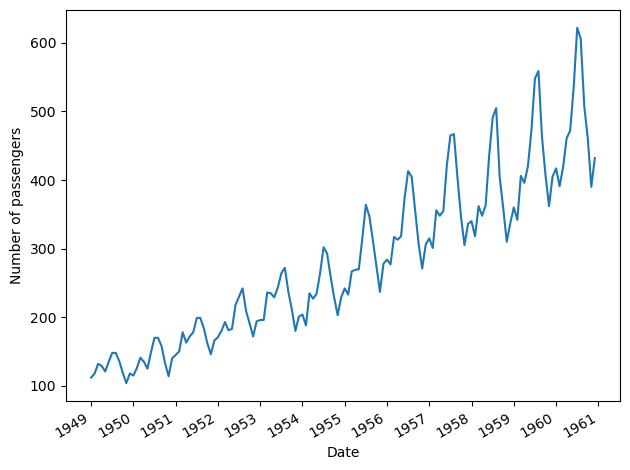

In [7]:
fig, ax=plt.subplots()

ax.plot(df['Month'],df['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of passengers')
plt.xticks(np.arange(0,145,12),np.arange(1949,1962,1))

fig.autofmt_xdate()
plt.tight_layout()

#### ***Monthly total number of air passengers for an airline, from January 1949 to December 1960. You’ll notice a clear seasonal pattern in the series, with peak traffic occurring toward the middle of each year.***

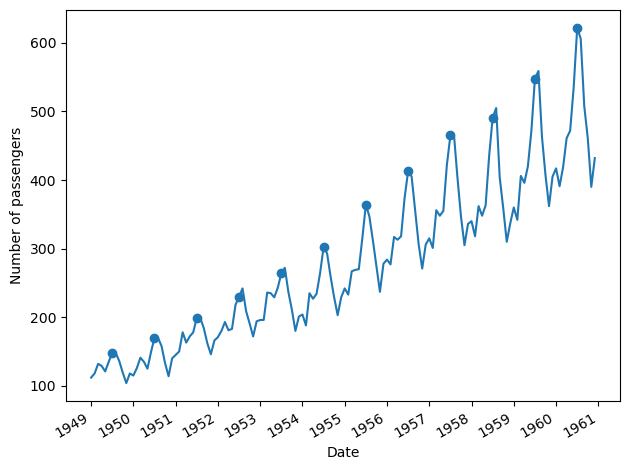

In [8]:
fig, ax=plt.subplots()

ax.plot(df['Month'],df['Passengers'],markevery=np.arange(6,145,12),marker='o')
ax.set_xlabel('Date')
ax.set_ylabel('Number of passengers')
plt.xticks(np.arange(0,145,12),np.arange(1949,1962,1))

fig.autofmt_xdate()
plt.tight_layout()

#### ***Marking the month of July of each year. You can see how the month of July has the highest number of air passengers. Therefore, it would make sense if July of the following year also saw the highest number of air passengers in the year. That kind of information ismcaptured by the seasonal parameters P, D, Q, and m of thenSARIMA(p,d,q)(P,D,Q)m model.***

## **---Identifying seasonal patterns in a time series---**

**Usually, plotting the time series data is enough to observe periodic patterns.
For example, looking at the total monthly air passengers in figure 8.3, it is
easy for us to identify a repeating pattern every year, with a high number of
passengers being recorded during June, July, and August of each year, and
fewer passengers in November, December, and January of each year.**

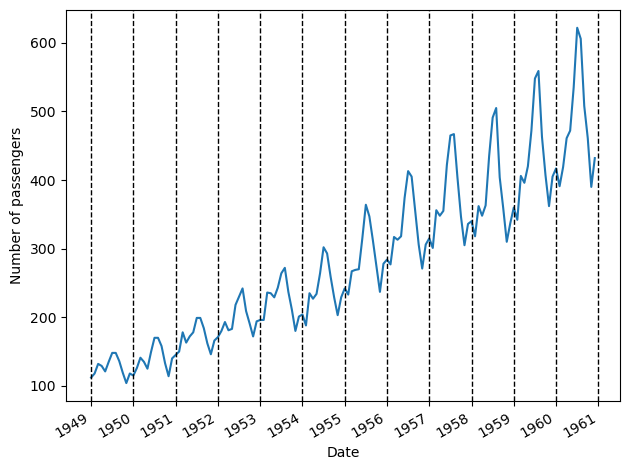

In [9]:
fig, ax=plt.subplots()
ax.plot(df['Month'],df['Passengers'])
for i in np.arange(0,145,12):
    ax.axvline(x=i,linestyle='--',color='black',linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Number of passengers')

plt.xticks(np.arange(0,145,12),np.arange(1949,1962,1))

fig.autofmt_xdate()
plt.tight_layout()

#### ***Highlighting the seasonal pattern in the monthly number of air passengers. The dashed vertical lines separate periods of twelve months. We can clearly see how a peak occurs in the middle of each year, and there is a very similar pattern for the beginning and end of each year. This observation is usually enough to determine that the dataset is seasonal.***

### **Another way of identifying seasonal patterns in a time series is using time series decomposition**

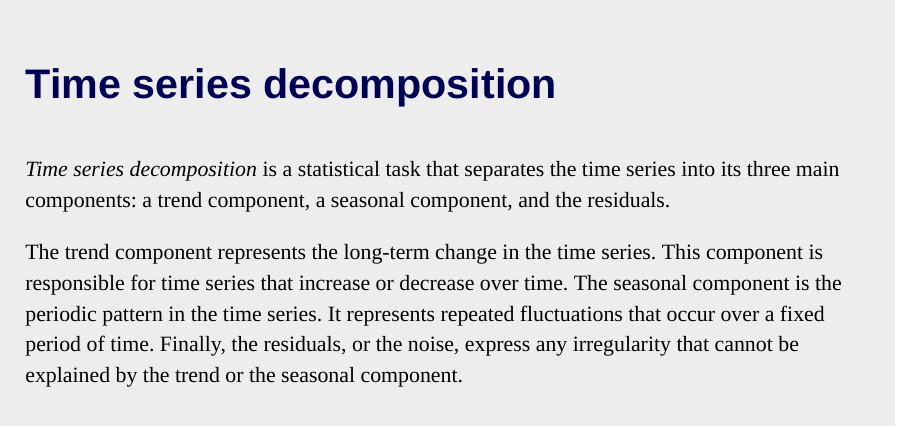

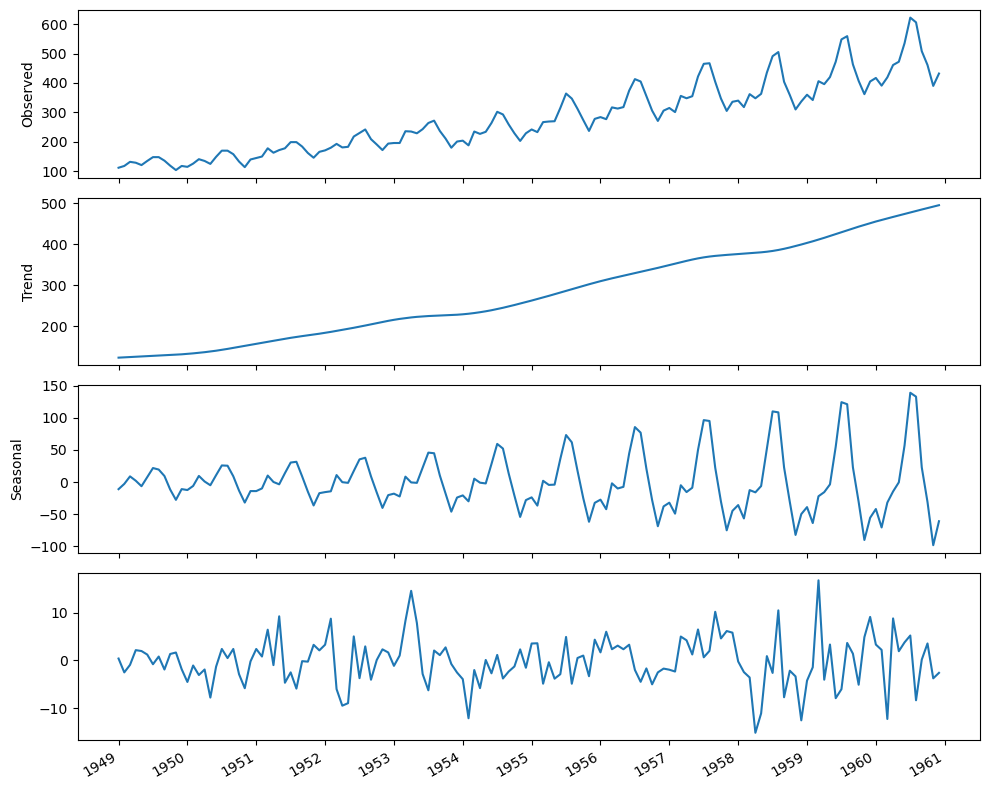

In [10]:
decomposition = STL(df['Passengers'], period=12).fit()
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True,figsize=(10,8))
ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax.set_ylabel('Residuals')

plt.xticks(np.arange(0,145,12),np.arange(1949,1962,1))

fig.autofmt_xdate()
plt.tight_layout()

#### ***Decomposing the dataset for air passengers. The first plot shows the observed data. The second plot shows the trend component,which tells us that the number of air passengers is increasing over time.The third plot displays the seasonal component, and we can clearly see a repeating pattern through time. Finally, the last plot shows the residuals, which are variations in the data that cannot be explained by the trend or the seasonal component.***

## **---Forecasting the number of monthly air passengers---**

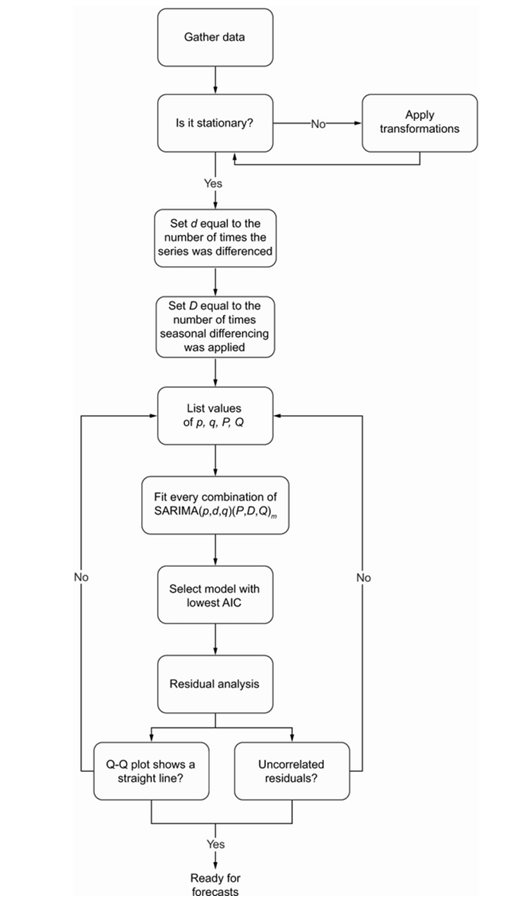

### ***General modeling procedure for the SARIMA model. Note that we can set P, D, and Q to 0 to obtain an ARIMA(p,d,q) model.***

## **Forecasting with an ARIMA(p,d,q) model**

**We’ll first model the dataset using an ARIMA(p,d,q) model. That way, we
can compare its performance to the SARIMA(p,d,q)(P,D,Q)m
 model.**

*Following the general modeling procedure we outlined before, we’ll first test
for stationarity. Again, we use the ADF test.*

In [11]:
adfuller(df['Passengers'])

(np.float64(0.8153688792060597),
 np.float64(0.9918802434376411),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

**As we can see that the p-value is greater than 0.05 and test statitics > table value so the data is not stationary, Now we apply differencing and then again check stationarity of our data**

In [12]:
df_diff=np.diff(df['Passengers'],n=1)
adfuller(df_diff)

(np.float64(-2.829266824169992),
 np.float64(0.0542132902838265),
 12,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(988.5069317854085))

**Still we can see that the p value is greater than 0.05 and test stattistic is greater than table value so now we perform differencing again and again check p vale**

In [13]:
df_diff2=np.diff(df_diff,n=1)
adfuller(df_diff2)

(np.float64(-16.384231542468527),
 np.float64(2.732891850014085e-29),
 11,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(988.60204172756))

**Now we can see that the p value is less than 0.05 and test statistic is less than table value**

Now we can define a range of possible values for the parameters p and q and
fit all unique ARIMA(p,d,q) models. We’ll specifically choose a range from
0 to 12 to allow the ARIMA model to go back 12 timesteps in time. Since
the data is sampled monthly and we know it is seasonal, we can hypothesize
that the number of air passengers in January of a given year is likely
predictive of the number of air passengers in January of the following year.
Since these two points are 12 timesteps apart, we’ll allow the values of p and
q to vary from 0 to 12 in order to potentially capture this seasonal
information in the ARIMA(p,d,q) model. Finally, since we are working with
an ARIMA model, we’ll set P, D, and Q to 0. Note the use of the parameter
s in the following code, which is equivalent to m. The implementation of
SARIMA in statsmodels simply uses s instead of m—they both denote
the frequency.

In [14]:
ps=range(0,13,1)
qs=range(0,13,1)
Ps=[0]
Qs=[0]
d=2
D=0
s=12
ARIMA_order_list=list(product(ps,qs,Ps,Qs))
ARIMA_order_list[:5]

[(0, 0, 0, 0), (0, 1, 0, 0), (0, 2, 0, 0), (0, 3, 0, 0), (0, 4, 0, 0)]

### **Defining a function to select the best SARIMA model**

In [15]:
def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog, 
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [16]:
train = df['Passengers'][:-12]

ARIMA_result_df = optimize_SARIMA(train, ARIMA_order_list, d, D, s)
ARIMA_result_df

  0%|          | 0/169 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(11, 3, 0, 0)",1016.901650
1,"(11, 4, 0, 0)",1019.013420
2,"(11, 5, 0, 0)",1020.416914
3,"(12, 0, 0, 0)",1020.665142
4,"(11, 1, 0, 0)",1021.028292
...,...,...
164,"(5, 0, 0, 0)",1281.732157
165,"(3, 0, 0, 0)",1300.282335
166,"(2, 0, 0, 0)",1302.913196
167,"(1, 0, 0, 0)",1308.152194


**This returns a DataFrame where the model with the lowest AIC is a
SARIMA(11,2,3)(0,0,0)12
 model, which is equivalent to an ARIMA(11,2,3)
model**

### **Analyzing residual**

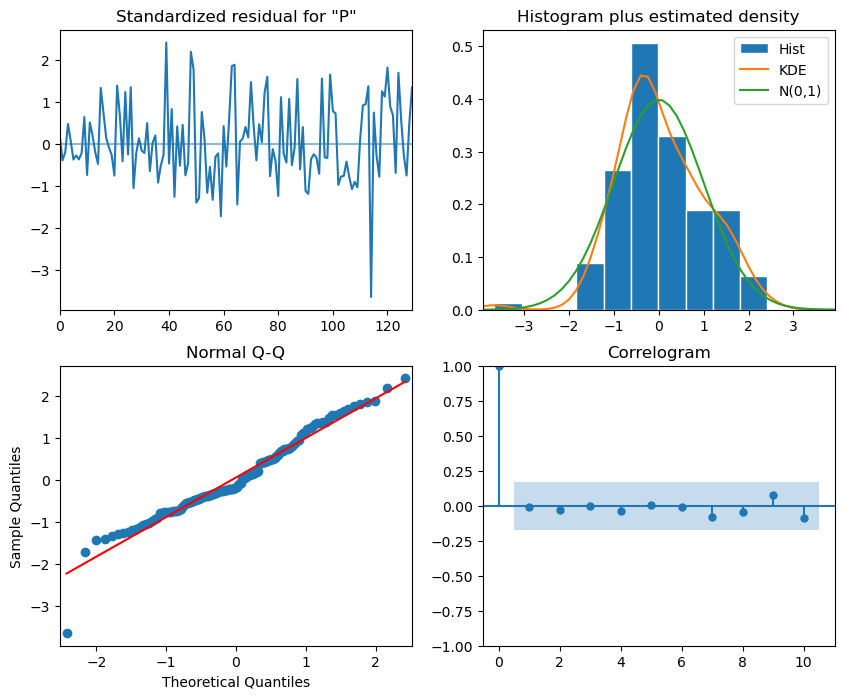

In [17]:
ARIMA_model = SARIMAX(train, order=(11,2,3), simple_differencing=False) 
ARIMA_model_fit = ARIMA_model.fit(disp=False) 
ARIMA_model_fit.plot_diagnostics(figsize=(10,8));

#### **Residuals’ diagnostics of the ARIMA(11,2,3) model. In the top-left plot, the residuals have no trend with a variance that seems fairly constant over time, which resembles the behavior of white noise.The top-right plot shows the distribution of the residuals, which approaches a normal distribution, despite the unusual peak. This is further confirmed by the Q-Q plot at the bottom left, which displays a fairly straight line that lies on y = x. Finally, the correlogram in the bottom-right plot shows no significant autocorrelation coefficients after lag 0, which is exactly like white noise. From this analysis, the residuals resemble white noise.**

**The next step is to run the Ljung-Box test on the residuals to make sure that
they are independent and uncorrelated.**

In [20]:
from statsmodels.stats.diagnostic import acorr_ljungbox 
residuals = ARIMA_model_fit.resid 
acorr_ljungbox(residuals, np.arange(1, 11, 1)) 

,lb_stat,lb_pvalue
1,6.568521,0.010380
2,6.685360,0.035342
3,6.934579,0.074012
4,7.766626,0.100511
5,8.398016,0.135622
6,8.723477,0.189737
7,9.604057,0.212143
8,9.829769,0.277178
9,9.839089,0.363668
10,11.630633,0.310537


*The returned p-values are all greater than 0.05 except for the first two
values. This means that, according to the Ljung-Box test, we reject the null
hypothesis with a 5% chance of being wrong, since we set our significance
boundary to 0.05. However, the third value and onwards are all greater than
0.05, so we reject the null hypothesis, concluding that the residuals are
uncorrelated starting at lag 3.
This is an interesting situation to dissect, because the graphical analysis of
the residuals leads us to conclude that they resemble white noise, but the
Ljung-Box test points to some correlation at lags 1 and 2. This means that
our ARIMA model is not capturing all the information from the data.*

**As previously mentioned, we wish to predict a full year of monthly air
passengers, using the last 12 months of data as our test set. The baseline
model is the naive seasonal forecast, where we simply use the number of air
passengers for each month of 1959 as a forecast for each month of 1960.**

In [23]:
test = df.iloc[-12:]                                             
test['naive_seasonal'] = df['Passengers'].iloc[120:132].values 

In [24]:
ARIMA_pred = ARIMA_model_fit.get_prediction(132, 143).predicted_mean    
test['ARIMA_pred'] = ARIMA_pred 

## **Forecasting with a SARIMA(p,d,q)(P,D,Q)m model**

**In the previous section, we used an ARIMA(11,2,3) model to forecast the
number of monthly air passengers. Now we’ll fit a SARIMA model and see
if it performs better than the ARIMA model. Hopefully the SARIMA model
will perform better, since it can capture seasonal information, and we know
that our dataset exhibits clear seasonality.**

#### ***Checking Stationarity***

In [25]:
adfuller(df['Passengers'])

(np.float64(0.8153688792060597),
 np.float64(0.9918802434376411),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

*P-value > 0.05 and test statistic > table value so we apply differencing and check stationarity again*

In [26]:
df_diff=np.diff(df['Passengers'],n=1)
adfuller(df_diff)

(np.float64(-2.829266824169992),
 np.float64(0.0542132902838265),
 12,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(988.5069317854085))

*We still can see that the p-value is greater than 0.05 and test statistic > table value so we again apply differencing but this time we apply seasonal differencing*

In [27]:
df_diff_seasonal_diff=np.diff(df_diff,n=12)
adfuller(df_diff_seasonal_diff)

(np.float64(-17.624862360181496),
 np.float64(3.823046855924265e-30),
 13,
 117,
 {'1%': np.float64(-3.487517288664615),
  '5%': np.float64(-2.8865777180380032),
  '10%': np.float64(-2.5801239192052012)},
 np.float64(1643.2206602594852))

**Now we can see that our data is stationary because p-value is less than 0.05 and test statistic is less than table value**

#### **With this step done, we can now define the range of possible values for p, q,P, and Q, fit each unique SARIMA(p,d,q)(P,D,Q)m model, and select the one with the lowest AIC**

In [28]:
ps=range(0,4,1)
qs=range(0,4,1)
Ps=range(0,4,1)
Qs=range(0,4,1)

SARIMA_order_list=list(product(ps,qs,Ps,Qs))

train=df['Passengers'][:-12]

d=1
D=1
s=12
SARIMA_result_df=optimize_SARIMA(train,SARIMA_order_list,d,D,s)
SARIMA_result_df

  0%|          | 0/256 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(1, 0, 2, 3)",14.000000
1,"(2, 1, 1, 2)",892.245790
2,"(2, 1, 2, 1)",893.782739
3,"(2, 1, 1, 3)",894.105452
4,"(1, 0, 1, 2)",894.288325
...,...,...
251,"(0, 0, 2, 0)",906.940147
252,"(3, 2, 0, 3)",907.181875
253,"(0, 0, 3, 2)",907.459390
254,"(0, 0, 3, 0)",908.742583


### **Residual analysis**

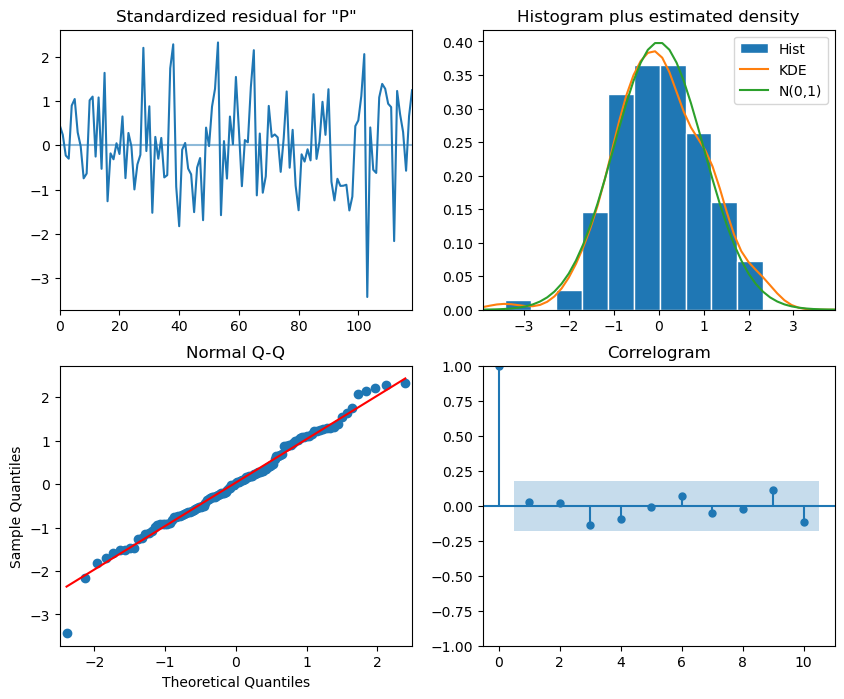

In [31]:
SARIMA_model=SARIMAX(train,order=(2,1,1),seasonal_order=(1,1,2,12),simple_differencing=False)
SARIMA_model_fit=SARIMA_model.fit(disp=False)
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

**Residuals’ diagnostics of the SARIMA(2,1,1)(1,1,2)12
 model.
The top-left plot shows that the residuals do not exhibit a trend or a
change in variance. The top-right plot shows that the residuals’
distribution is very close to a normal distribution. This is further
supported by the Q-Q plot at the bottom left, which displays a fairly
straight line that lies on y = x. Finally, the correlogram at the bottom
right shows no significant coefficients after lag 0. Therefore, everything
leads to the conclusion that the residuals resemble white noise.**

### **The final test to determine whether we can use this model for forecasting or not is the Ljung-Box test.**

In [32]:
from statsmodels.stats.diagnostic import acorr_ljungbox 
residuals = SARIMA_model_fit.resid 
acorr_ljungbox(residuals, np.arange(1, 11, 1)) 

,lb_stat,lb_pvalue
1,0.005806,0.939262
2,0.738495,0.691254
3,1.011658,0.798431
4,1.219051,0.874952
5,1.431706,0.920814
6,1.704881,0.944744
7,2.298953,0.941461
8,2.708801,0.951283
9,2.724690,0.974218
10,4.958987,0.893901


**The returned p-values are all greater than 0.05. Therefore, we do not reject
the null hypothesis, and we conclude that the residuals are independent and
uncorrelated, just like white noise.**

In [33]:
SARIMA_pred = SARIMA_model_fit.get_prediction(132, 143).predicted_mean   
test['SARIMA_pred'] = SARIMA_pred

## **Comparing the performance of each forecasting method**

#### **We can first visualize the forecasts against the observed values of the test set**

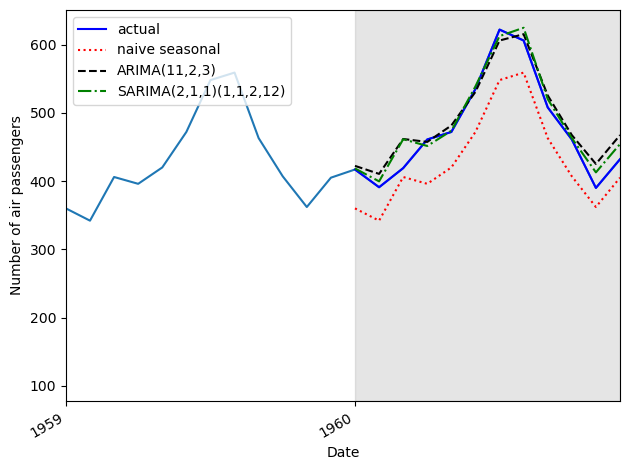

In [34]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.plot(test['Passengers'], 'b-', label='actual')
ax.plot(test['naive_seasonal'], 'r:', label='naive seasonal')
ax.plot(test['ARIMA_pred'], 'k--', label='ARIMA(11,2,3)')
ax.plot(test['SARIMA_pred'], 'g-.', label='SARIMA(2,1,1)(1,1,2,12)')

ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')
ax.axvspan(132, 143, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))
ax.set_xlim(120, 143)

fig.autofmt_xdate()
plt.tight_layout()

**Forecasts of the number of monthly air passengers. The
shaded area designates the test set. You can see that the curves coming
from the ARIMA and SARIMA models almost obscure the observed
data, which is indicative of good predictions.**

### **We can measure the MAPE of each model and display it in a bar plot**

In [36]:
def mape(y_true, y_pred):                                               
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100 
mape_naive_seasonal = mape(test['Passengers'], test['naive_seasonal'])
mape_ARIMA = mape(test['Passengers'], test['ARIMA_pred']) 
mape_SARIMA = mape(test['Passengers'], test['SARIMA_pred']) 

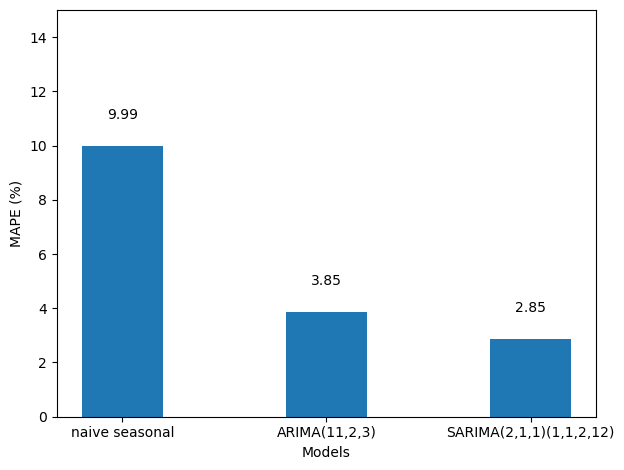

In [39]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'ARIMA(11,2,3)', 'SARIMA(2,1,1)(1,1,2,12)']
y = [mape_naive_seasonal, mape_ARIMA, mape_SARIMA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()


### **The MAPE of all forecasting methods. You can see that the best-performing model is the SARIMA model, since it has the lowest MAPE of all methods.**